In [911]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import SimpleITK as sitk
import os
import pytomography
from pytomography.io.SPECT import dicom
from pytomography.projectors.SPECT import SPECTSystemMatrix
from pytomography.algorithms import OSEM
from pytomography.likelihoods import PoissonLogLikelihood
from pytomography.transforms.SPECT import SPECTAttenuationTransform, SPECTPSFTransform
from pytomography.utils import plot_utils, ESSEScatterModel
from pytomography.metadata.SPECT import SPECTObjectMeta, SPECTProjMeta
import json

In [912]:
current_dir = os.getcwd()
DATADIR = os.path.join(current_dir, '../../../src/pytomography/data/NIST_attenuation_data')
FILE_WATER = os.path.join(DATADIR, 'water.csv')

In [913]:
# import json
# import numpy as np
# import SimpleITK as sitk
# import torch
# import pytomography

# # 1. Chargement de l'image de labels (l'image 3D générée par Gate)
# path_labels = '../../../../simulations-kernel-esse/validation_tests/nema_final_sim/nema_voxelized.mhd'
# img_sitk = sitk.ReadImage(path_labels)
# labels_array = sitk.GetArrayFromImage(img_sitk)

# # 2. Définition des densités (extraites de ton fichier .db)
# # Unités : g/cm3
# material_densities = {
#     "IEC_PLASTIC": 1.18,
#     "G4_WATER": 1.0,
#     "G4_LUNG_ICRP": 1.04,
#     "G4_AIR": 0.00120479  # 1.20479 mg/cm3 -> g/cm3
# }


# # 3. Chargement du mapping Volume -> Label/Material
# path_volumes = '../../../../simulations-kernel-esse/validation_tests/nema_final_sim/nema_voxelized_volumes.json'
# with open(path_volumes, "r") as f:
#     volumes_mapping = json.load(f)

# # 4. Calcul du mu de l'eau à 208 keV (référence NIST)
# # mu_water_ref est en cm^-1
# mu_water_ref = pytomography.utils.get_mu_from_spectrum_interp(FILE_WATER, 208.0)

# # 5. Création de la carte de mu
# mu_map = np.zeros_like(labels_array, dtype=np.float32)

# # On parcourt chaque volume défini pour assigner sa valeur de mu
# for vol_name, info in volumes_mapping.items():
#     label = info['label']
#     material = info['material']
    
#     # mu_local = (densité_matériau / densité_eau) * mu_eau_ref
#     # On approxime ici que (mu/rho) est similaire pour ces matériaux à 208 keV
#     # sinon on peut charger chaque matériau spécifiquement
#     density_ratio = material_densities[material] / material_densities["G4_WATER"]
#     mu_val = density_ratio * mu_water_ref
    
#     mu_map[labels_array == label] = mu_val

# # 6. Conversion en Tensor pour PyTomography
# attenuation_map = torch.tensor(mu_map).to(pytomography.device)

# print(f"Carte mu générée avec succès.")
# print(f"Valeur mu Eau : {mu_water_ref:.4f} cm^-1")
# print(f"Valeur mu Plastique : {mu_map.max():.4f} cm^-1")

In [914]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(6, 5))
# slice_idx = attenuation_map.shape[0] // 2
# plt.imshow(mu_map[slice_idx], cmap='hot')
# plt.colorbar(label='linear attenuation coefficient mu (cm^-1)')
# plt.title(f"Coupe centrale de la mu-map (z={slice_idx})")
# plt.axis('off')
# plt.show()

In [915]:
def plot_mhd(mhd_path, title="Mu-Map à 208 keV", pos=[None, None, None]):
    img = sitk.ReadImage(mhd_path)
    data = sitk.GetArrayFromImage(img)
    cz, cy, cx = [s // 2 for s in data.shape]
    if pos[0] is not None:
        cz = min(pos[0], data.shape[0] - 1)
    if pos[1] is not None:
        cy = min(pos[1], data.shape[1] - 1)
    if pos[2] is not None:
        cx = min(pos[2], data.shape[2] - 1)

    # --- Définition du référentiel commun ---
    # Pour du 208 keV : 0 (Air) à 0.16 (Plastique dense)
    v_min, v_max = 0.0, 0.16 

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title}\nSpacing: {img.GetSpacing()}", fontsize=14)

    views = [
        (data[cz, :, :], f"Axial (Z={cz})"),
        (data[:, cy, :], f"Coronal (Y={cy})"),
        (data[:, :, cx], f"Sagittal (X={cx})")
    ]

    for i, (slice_data, label) in enumerate(views):
        im = axes[i].imshow(slice_data, cmap='viridis', origin='lower', 
                            vmin=v_min, vmax=v_max) # <--- Échelle fixe
        axes[i].set_title(label)
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04, label="$\mu$ ($cm^{-1}$)")

    plt.tight_layout()
    plt.show()

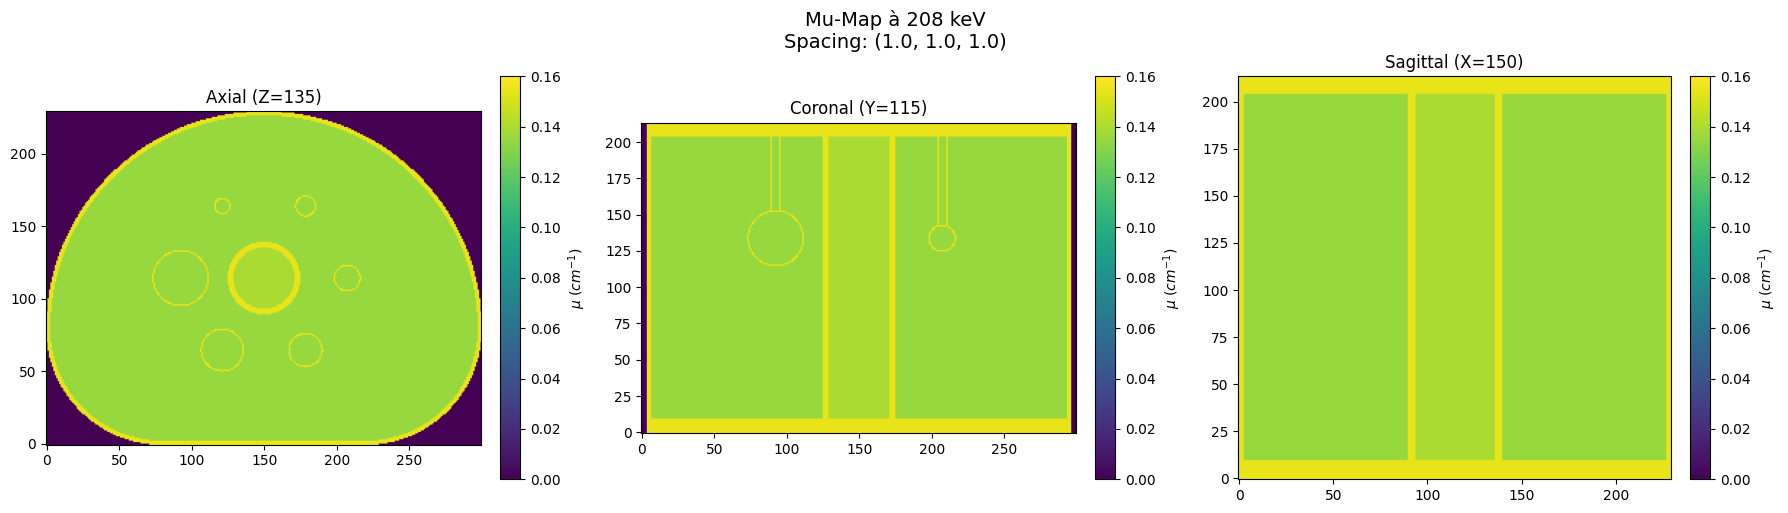

In [916]:
path_mu = "../../../../simulations-kernel-esse/validation_tests/nema_maps/nema_mu_map_208keV.mhd"
plot_mhd(path_mu, title="Mu-Map à 208 keV",pos=[135, None, None])

In [917]:
config = {
    "num_projections": 5,
    "pixel_size_cm": 0.44,
    "matrix_size": 128,
    "filenames": {
        "primary": "projections_primary.mhd",
        "scatter": "projections_scatter.mhd",
        "total": "projections_total.mhd"
    },
    "raws": {
        "primary": "projections_primary.raw",
        "scatter": "projections_scatter.raw",
        "total": "projections_total.raw"
    }
}

# path = '../../../../simulations-kernel-esse/validation_tests/output_spect_res_simu_we/'
path = '../../../../simulations-kernel-esse/validation_tests/output_spect/'

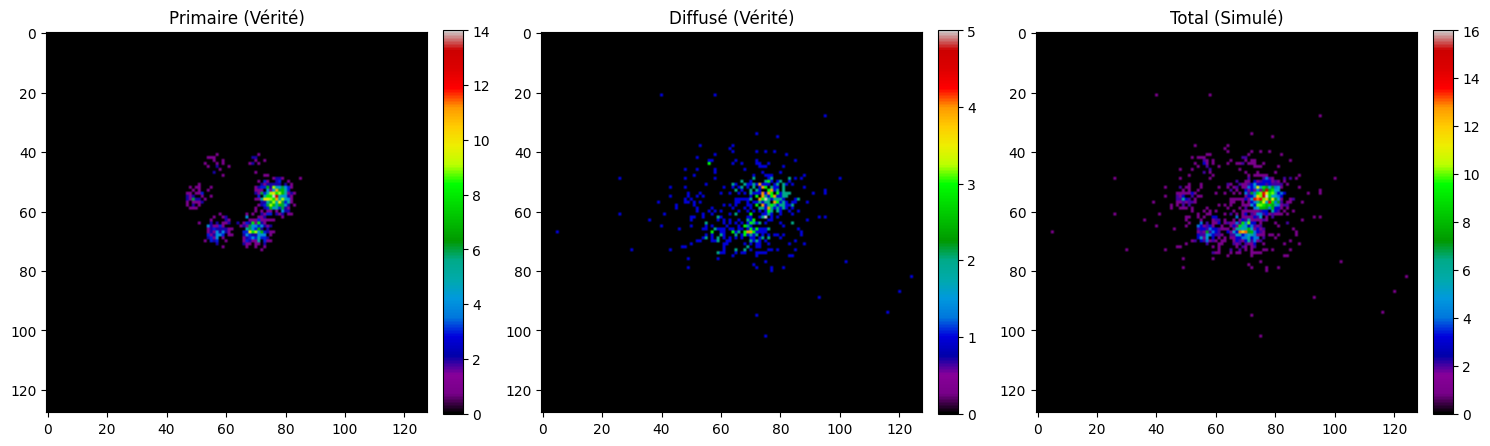

In [918]:
def load_gate_projection(filename):
    img = sitk.ReadImage(filename)
    data = sitk.GetArrayFromImage(img)
    return torch.tensor(data.astype(np.float32))

# Chargement des données
proj_primary = load_gate_projection(path + config["filenames"]["primary"])
proj_scatter = load_gate_projection(path + config["filenames"]["scatter"])
proj_total = load_gate_projection(path + config["filenames"]["total"])

# Affichage d'une projection (ex: angle 0)
angle_idx = 0
plt.figure(figsize=(15, 5))
titles = ['Primaire (Vérité)', 'Diffusé (Vérité)', 'Total (Simulé)']
projs = [proj_primary[angle_idx], proj_scatter[angle_idx], proj_total[angle_idx]]

for i, (p, t) in enumerate(zip(projs, titles)):
    plt.subplot(1, 3, i+1)
    plt.title(t)
    plt.imshow(p.cpu(), cmap='nipy_spectral')
    plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [919]:
def check_raw_integrity(filepath, shape=(20, 128, 128)):
    if not os.path.exists(filepath):
        print(f"Fichier introuvable : {filepath}")
        return

    # Lecture du binaire brut (float32 car MET_FLOAT dans votre mhd)
    data = np.fromfile(filepath, dtype=np.float32)
    
    print(f"--- Analyse de {os.path.basename(filepath)} ---")
    print(f"Nombre total d'éléments : {data.size}")
    print(f"Somme totale des comptes : {data.sum()}")
    print(f"Valeur Max : {data.max()}")
    print(f"Valeur Min : {data.min()}")
    print(f"Nombre de pixels non nuls : {np.count_nonzero(data)}")
    

check_raw_integrity(os.path.join(path, config["raws"]["primary"]))
check_raw_integrity(os.path.join(path, config["raws"]["scatter"]))
check_raw_integrity(os.path.join(path, config["raws"]["total"]))

--- Analyse de projections_primary.raw ---
Nombre total d'éléments : 49152
Somme totale des comptes : 2841.0
Valeur Max : 24.0
Valeur Min : 0.0
Nombre de pixels non nuls : 940
--- Analyse de projections_scatter.raw ---
Nombre total d'éléments : 49152
Somme totale des comptes : 1714.0
Valeur Max : 8.0
Valeur Min : 0.0
Nombre de pixels non nuls : 1171
--- Analyse de projections_total.raw ---
Nombre total d'éléments : 49152
Somme totale des comptes : 4555.0
Valeur Max : 30.0
Valeur Min : 0.0
Nombre de pixels non nuls : 1593


In [920]:


path = '../../../../simulations-kernel-esse/validation_tests/nema_final_sim/projections_nema_counts.raw'

check_raw_integrity(path)

Fichier introuvable : ../../../../simulations-kernel-esse/validation_tests/nema_final_sim/projections_nema_counts.raw


In [921]:
path = '/home/chloe/SPECT'  # Personal computer

# pathCT = os.path.join(path, 'Lu177-NEMA-SymT2', 'CT')
# files_CT = [os.path.join(pathCT, file) for file in os.listdir(pathCT)]

attenuation_map_path = "../../../../simulations-kernel-esse/validation_tests/nema_maps/nema_mu_map_208keV.mhd"

img = sitk.ReadImage(attenuation_map_path)
attenuation_map_np = sitk.GetArrayFromImage(img)
attenuation_map = torch.from_numpy(attenuation_map_np.astype(np.float32)).to(pytomography.device)



In [922]:
pytomography.device = 'cpu'
pytomography.dtype = torch.float32

energy = 208.0
nb_iter=20
nb_subset=8
index_peak = 0
photopeak_total = proj_total.to(pytomography.device)
photopeak_primary = proj_primary.to(pytomography.device)

In [923]:
# object_meta, proj_meta = dicom.get_metadata(file_NM)
projections = photopeak_total
projections_primary = photopeak_primary
# attenuation_map_total = dicom.get_attenuation_map_from_CT_slices(files_CT, photopeak_total)
# attenuation_map_primary = dicom.get_attenuation_map_from_CT_slices(files_CT, photopeak_primary)

# attenuation_map_total = attenuation_map
# attenuation_map_primary = attenuation_map
mu_water = pytomography.utils.get_mu_from_spectrum_interp(FILE_WATER, energy)

In [924]:

collimator_name = 'SY-ME'               #todo: automatiser la récupération du collimateur à partir des métadonnées 
energy_kev = energy
intrinsic_resolution=0.35 # todo : à vérifier ??
psf_meta = dicom.get_psfmeta_from_scanner_params(
        collimator_name,
        energy_kev,
        intrinsic_resolution=intrinsic_resolution
)
psf_transform = SPECTPSFTransform(psf_meta)

with open("../../../../simulations-kernel-esse/validation_tests/output_spect/metadata_pytomography.json", "r") as f:
    meta_json = json.load(f)

# Instanciation automatique
proj_meta = SPECTProjMeta(
    projection_shape=(meta_json['simulation_params']['matrix_size'], 
                      meta_json['simulation_params']['matrix_size']),
    angles=np.array(meta_json['geometry']['angles']),
    radii=np.array(meta_json['geometry']['radii_cm']),
    dr=(meta_json['simulation_params']['pixel_size_cm'], 
        meta_json['simulation_params']['pixel_size_cm'])
)

object_meta = SPECTObjectMeta(
    dr = (meta_json['simulation_params']['pixel_size_cm'], 
          meta_json['simulation_params']['pixel_size_cm'],
          meta_json['simulation_params']['pixel_size_cm']   
    ),
    shape= (meta_json['simulation_params']['matrix_size'], 
            meta_json['simulation_params']['matrix_size'],
            meta_json['simulation_params']['matrix_size']
    )
)

In [925]:
import torch.nn.functional as F

def resample_mu_map(mu_map, object_meta):
    """
    Redimensionne la Mu-Map 3D pour correspondre à la grille de reconstruction.
    """
    # mu_map est un tenseur (Z, Y, X)
    # F.interpolate attend (Batch, Channel, Z, Y, X)
    mu_tensor = mu_map.unsqueeze(0).unsqueeze(0)
    
    # On récupère la shape cible depuis object_meta
    target_shape = object_meta.shape # ex: (128, 128, 128)
    
    # Interpolation trilinéaire
    resampled = F.interpolate(
        mu_tensor, 
        size=target_shape, 
        mode='trilinear', 
        align_corners=False
    ).squeeze()
    
    return resampled

# --- Application ---

mu_aligned = resample_mu_map(attenuation_map, object_meta)
attenuation_map_total = mu_aligned
attenuation_map_primary = mu_aligned
att_transform_total = SPECTAttenuationTransform(attenuation_map=mu_aligned)
att_transform_primary = SPECTAttenuationTransform(attenuation_map=mu_aligned)

In [926]:
system_matrix_no_correction = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_total, psf_transform],
    proj2proj_transforms=[],
    object_meta=object_meta,
    proj_meta=proj_meta
)

likelihood_no_correction = PoissonLogLikelihood(system_matrix_no_correction, photopeak_total)
algorithm_no_correction = OSEM(likelihood_no_correction)

In [927]:
recon_no_correction = algorithm_no_correction(n_iters=nb_iter, n_subsets=nb_subset)

In [928]:
system_matrix_no_scatter = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_primary, psf_transform],
    proj2proj_transforms=[],
    object_meta=object_meta,
    proj_meta=proj_meta
)

likelihood_no_scatter = PoissonLogLikelihood(system_matrix_no_scatter, photopeak_primary)
algorithm_no_scatter = OSEM(likelihood_no_scatter)

In [929]:
recon_no_scatter = algorithm_no_scatter(n_iters=nb_iter, n_subsets=nb_subset)

In [930]:
# index_peak, index_lower, index_upper = 1, 0, 2
# scatter_TEW = dicom.get_energy_window_scatter_estimate_projections(file_NM, projections, index_peak=index_peak, index_lower=index_lower, index_upper=index_upper, sigma_theta=2, sigma_r=0.48, sigma_z=0.48, proj_meta=proj_meta)

# system_matrix_TEW = SPECTSystemMatrix(
#         obj2obj_transforms = [att_transform_total, psf_transform],
#         proj2proj_transforms = [],
#         object_meta = object_meta,
#         proj_meta = proj_meta)

# likelihood_TEW = PoissonLogLikelihood(system_matrix_TEW, photopeak_total, scatter_TEW)
# algorithm_TEW = OSEM(likelihood_TEW)

In [931]:
npy_file = '../../../../simulations-kernel-esse/output/esse_kernels_3d.npy'
npy_file_amu = '../../../../simulations-kernel-esse/output/esse_amu_kernels_3d.npy'

from scipy.ndimage import gaussian_filter
def get_real_esse_kernels(npy_path, npy_path_amu, grid_size):

    Z_t, Y_t, X_t = grid_size

    # --- LOAD ---
    raw_k0 = np.load(npy_path)
    raw_amu = np.load(npy_path_amu)

    # raw_k0 = gaussian_filter(raw_k0, sigma=(1.5, 0, 1.5))
    # raw_amu = gaussian_filter(raw_amu, sigma=(1.5, 0, 1.5))

    # --- FORMAT ---
    if raw_k0.ndim == 3:
        k0 = np.transpose(raw_k0, (1, 2, 0))
        amu = np.transpose(raw_amu, (1, 2, 0))
    else:
        k0 = raw_k0
        amu = raw_amu

    # --- TAYLOR TERMS ---
    K0 = k0
    K1 = k0 * amu
    K2 = 0.5 * k0 * (amu ** 2)

    def pad_kernel(data):
        Z_s, Y_s, X_s = data.shape 

        pad_z = Z_t - Z_s
        pad_y = Y_t - Y_s
        pad_x = X_t - X_s

        paddings = (
            pad_x // 2, pad_x - (pad_x // 2), # Dim X
            pad_y // 2, pad_y - (pad_y // 2), # Dim Y
            pad_z // 2, pad_z - (pad_z // 2)  # Dim Z
        )

        tensor = torch.from_numpy(data).float()
        return torch.nn.functional.pad(tensor, paddings)

    # --- APPLY PADDING ---
    k0_t = pad_kernel(K0)
    k1_t = pad_kernel(K1)
    k2_t = pad_kernel(K2)

    # --- STACK FINAL ---
    final_kernels = torch.stack([
        k0_t,
        k1_t,
        k2_t
    ])

    return final_kernels

In [932]:
# Initilization

esse = ESSEScatterModel(
    object_meta=object_meta,
    attenuation_map=attenuation_map_total,
    energy=208.4,
    mu_water=mu_water,
    kernels=get_real_esse_kernels(
        npy_path=npy_file,
        npy_path_amu=npy_file_amu,
        grid_size=object_meta.padded_shape
    )
)

system_matrix_ESSE = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_total, psf_transform],
    proj2proj_transforms = [],
    object_meta = object_meta,
    proj_meta = proj_meta,
    scatter_model=esse
)

likelihood_ESSE = PoissonLogLikelihood(system_matrix_ESSE, photopeak_total)
algorithm_ESSE = OSEM(likelihood_ESSE)

In [933]:
recon_ESSE = algorithm_ESSE(n_iters=nb_iter, n_subsets=nb_subset)

In [934]:
def plot_comparative_spect(recon1, recon2, vmax, label1, label2, slice_idx=None):
    if slice_idx is None:
        slice_idx = recon1.shape[-1] // 2
    vmax = vmax if vmax is not None else max(recon1.max().item(), recon2.max().item())

    recon1_CPU = recon1.cpu().numpy() if hasattr(recon1, 'is_cuda') and recon1.is_cuda else (recon1.numpy() if hasattr(recon1, 'numpy') else recon1)
    recon2_CPU = recon2.cpu().numpy() if hasattr(recon2, 'is_cuda') and recon2.is_cuda else (recon2.numpy() if hasattr(recon2, 'numpy') else recon2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # RECONSTRUCTION 1
    im1 = axes[0].imshow(recon1_CPU[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
    axes[0].set_title(f'{label1} ({nb_iter} iter, {nb_subset} subsets)')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], label='Intensity')

    # RECONSTRUCTION 2
    im2 = axes[1].imshow(recon2_CPU[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
    axes[1].set_title(f'{label2} ({nb_iter} iter, {nb_subset} subsets)')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], label='Intensity')

    # DIFFÉRENCE
    diff = recon1_CPU - recon2_CPU
    im3 = axes[2].imshow(diff[:, :, slice_idx], cmap='RdBu_r', origin='lower', vmin=-vmax/2, vmax=vmax/2)
    axes[2].set_title(f'Différence ({label1} - {label2})')
    axes[2].axis('off')
    plt.colorbar(im3, ax=axes[2], label='Δ Intensity')

No correction reconstruction value range: [0.000, 30.000]


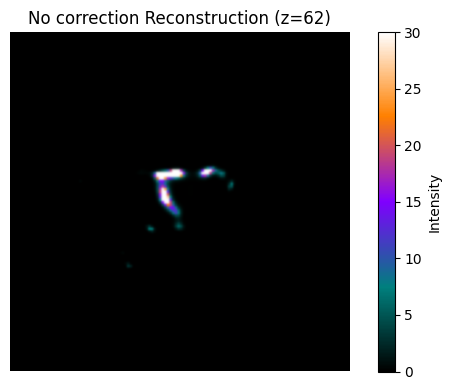

In [935]:
recon_max = recon_no_correction.max().item()
recon_min = recon_no_correction.min().item()
recon_max = 30
print(f"No correction reconstruction value range: [{recon_min:.3f}, {recon_max:.3f}]")

SPECT_imshow_kwargs = {
    'cmap': plot_utils.pet_cmap,
    'interpolation': 'Gaussian',
    'alpha': 1,
    'vmin': recon_min,
    'vmax': recon_max,
    'zorder': 1,
    'origin': 'lower'
}

slice_idx = 62

plt.figure(figsize=(6, 4))
plt.title(f'No correction Reconstruction (z={slice_idx})')
plt.imshow(recon_no_correction.cpu()[:, :, slice_idx], **SPECT_imshow_kwargs)
plt.colorbar(label='Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()

No scatter reconstruction value range: [0.000, 30.000]


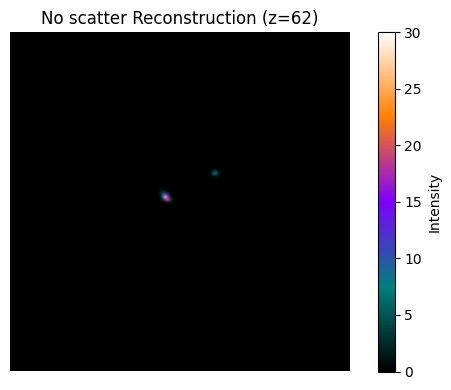

In [936]:
recon_max = recon_no_scatter.max().item()
recon_min = recon_no_scatter.min().item()
recon_max = 30
print(f"No scatter reconstruction value range: [{recon_min:.3f}, {recon_max:.3f}]")

SPECT_imshow_kwargs = {
    'cmap': plot_utils.pet_cmap,
    'interpolation': 'Gaussian',
    'alpha': 1,
    'vmin': recon_min,
    'vmax': recon_max,
    'zorder': 1,
    'origin': 'lower'
}

slice_idx = 62

plt.figure(figsize=(6, 4))
plt.title(f'No scatter Reconstruction (z={slice_idx})')
plt.imshow(recon_no_scatter.cpu()[:, :, slice_idx], **SPECT_imshow_kwargs)
plt.colorbar(label='Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()

ESSE reconstruction value range: [0.000, 30.000]


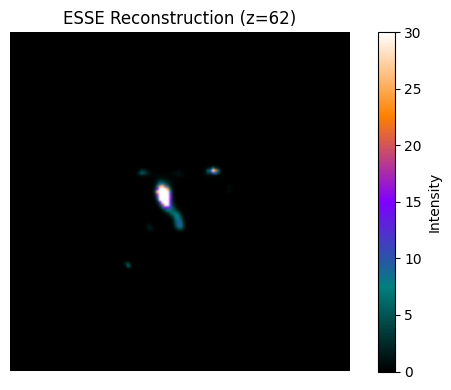

Sum of voxels in recon_no_correction: 1.16e+05
Sum of voxels in recon_no_scatter: 8.35e+04
Sum of voxels in recon_ESSE: 7.50e+04


In [937]:
recon_max = recon_ESSE.max().item()
recon_min = recon_ESSE.min().item()
recon_max = 30
print(f"ESSE reconstruction value range: [{recon_min:.3f}, {recon_max:.3f}]")

SPECT_imshow_kwargs = {
    'cmap': plot_utils.pet_cmap,
    'interpolation': 'Gaussian',
    'alpha': 1,
    'vmin': recon_min,
    'vmax': recon_max,
    'zorder': 1,
    'origin': 'lower'
}

slice_idx = 62

plt.figure(figsize=(6, 4))
plt.title(f'ESSE Reconstruction (z={slice_idx})')
plt.imshow(recon_ESSE.cpu()[:, :, slice_idx], **SPECT_imshow_kwargs)
plt.colorbar(label='Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()

#print the sum of all voxels in the reconstructions
print(f"Sum of voxels in recon_no_correction: {recon_no_correction.sum().item():.2e}")
print(f"Sum of voxels in recon_no_scatter: {recon_no_scatter.sum().item():.2e}")
print(f"Sum of voxels in recon_ESSE: {recon_ESSE.sum().item():.2e}")

In [946]:
slice_idx = 62
print(f"Max value in recon_no_correction (z={slice_idx}): {recon_no_correction[:, :, slice_idx].max().item():.3f}")
print(f"Max value in recon_no_scatter (z={slice_idx}): {recon_no_scatter[:, :, slice_idx].max().item():.3f}")
print(f"Max value in recon_ESSE (z={slice_idx}): {recon_ESSE[:, :, slice_idx].max().item():.3f}")

print(f"Sum of voxels in recon_no_correction (z={slice_idx}): {recon_no_correction[:, :, slice_idx].sum().item():.2e}")
print(f"Sum of voxels in recon_no_scatter (z={slice_idx}): {recon_no_scatter[:, :, slice_idx].sum().item():.2e}")
print(f"Sum of voxels in recon_ESSE (z={slice_idx}): {recon_ESSE[:, :, slice_idx].sum().item():.2e}")      

Max value in recon_no_correction (z=62): 171.231
Max value in recon_no_scatter (z=62): 26.956
Max value in recon_ESSE (z=62): 248.837
Sum of voxels in recon_no_correction (z=62): 3.63e+03
Sum of voxels in recon_no_scatter (z=62): 1.68e+02
Sum of voxels in recon_ESSE (z=62): 3.58e+03


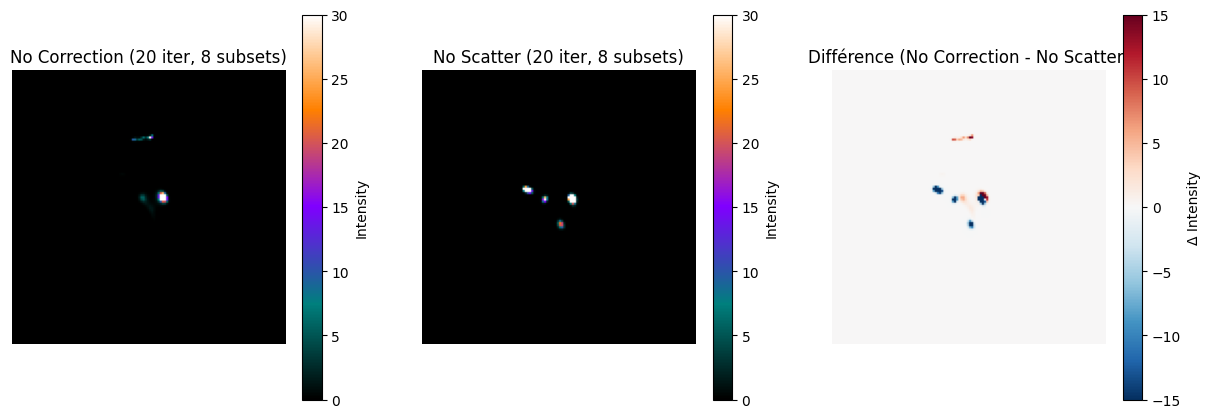

In [ ]:
plot_comparative_spect(
    recon_no_correction, 
    recon_no_scatter, 
    vmax=30, 
    label1="No Correction", 
    label2="No Scatter", 
    slice_idx=slice_idx
)

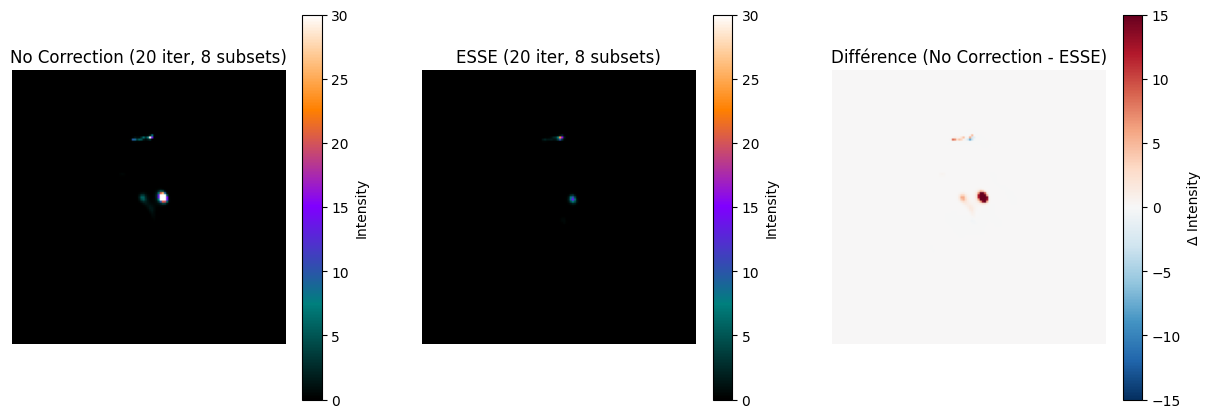

In [ ]:
plot_comparative_spect(
    recon_no_correction, 
    recon_ESSE, 
    vmax=30, 
    label1="No Correction", 
    label2="ESSE", 
    slice_idx=slice_idx
    
)

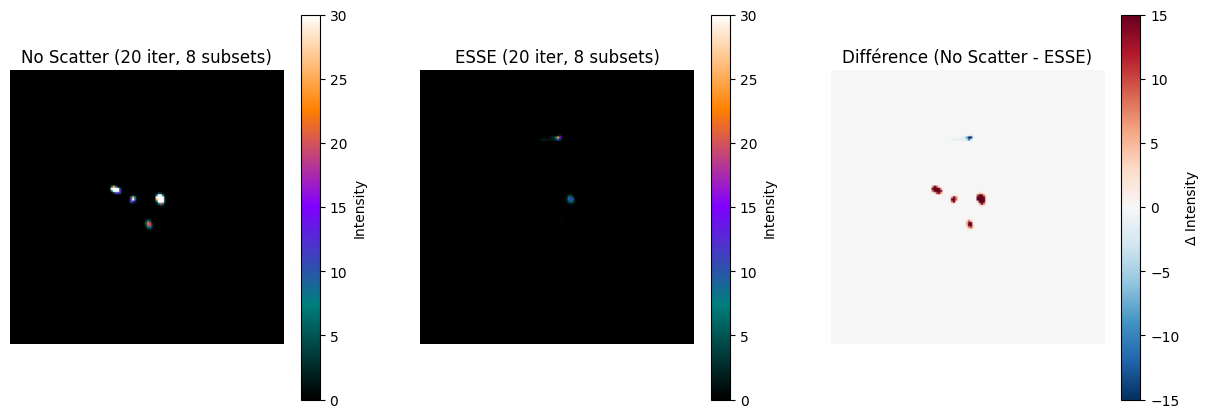

In [ ]:
plot_comparative_spect(
    recon_no_scatter, 
    recon_ESSE, 
    vmax=30, 
    label1="No Scatter", 
    label2="ESSE", 
    slice_idx=slice_idx
)